In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 8)

In [2]:
amir_deals = pd.read_csv('amir_deals.csv', index_col=0)
amir_deals.head()

,product,client,status,amount,num_users
1,Product F,Current,Won,7389.52,19
2,Product C,New,Won,4493.01,43
3,Product B,New,Won,5738.09,87
4,Product I,Current,Won,2591.24,83
5,Product E,Current,Won,6622.97,17


In [4]:
#Menghitung Jumlah Transaksi
counts = amir_deals['product'].value_counts()
print("Jumlah Transaksi per produk:\n", counts)

# Menghitung Probabilitas untuk setiap produk
probs = counts / counts.sum()
print("\nProbabilitas memilik transaksi per produk:\n", probs)

Jumlah Transaksi per produk:
 product
Product B    62
Product D    40
Product A    23
Product C    15
Product F    11
Product H     8
Product I     7
Product E     5
Product N     3
Product G     2
Product J     2
Name: count, dtype: int64

Probabilitas memilik transaksi per produk:
 product
Product B    0.348315
Product D    0.224719
Product A    0.129213
Product C    0.084270
Product F    0.061798
Product H    0.044944
Product I    0.039326
Product E    0.028090
Product N    0.016854
Product G    0.011236
Product J    0.011236
Name: count, dtype: float64


In [5]:
# Menetapkan seed acak untuk hasil yang konsisten
np.random.seed(24)

# Mengambil sampel 5 transaksi unik tanpa penggantian
sampel_5_transaksi = amir_deals.sample(n=5, replace=False)
print(sampel_5_transaksi)


       product   client status   amount  num_users
128  Product B  Current    Won  2070.25          7
149  Product D  Current    Won  3485.48         52
78   Product B  Current    Won  6252.30         27
105  Product D  Current    Won  4110.98         39
167  Product C      New   Lost  3779.86         11


In [6]:
# Mengatur seed acak untuk konsistensi hasil
np.random.seed(24)

# Melakukan sampling 5 transaksi dengan penggantian
sampel_5_dengan_penggantian = amir_deals.sample(n=5, replace=True)
print(sampel_5_dengan_penggantian)


       product   client status   amount  num_users
163  Product D  Current    Won  6755.66         59
132  Product B  Current    Won  6872.29         25
88   Product C  Current    Won  3579.63          3
146  Product A  Current    Won  4682.94         63
146  Product A  Current    Won  4682.94         63


In [7]:
restaurant_groups = pd.read_csv('restaurant_groups.csv')
restaurant_groups.head()

,group_id,group_size
0,A,2
1,B,4
2,C,6
3,D,2
4,E,2


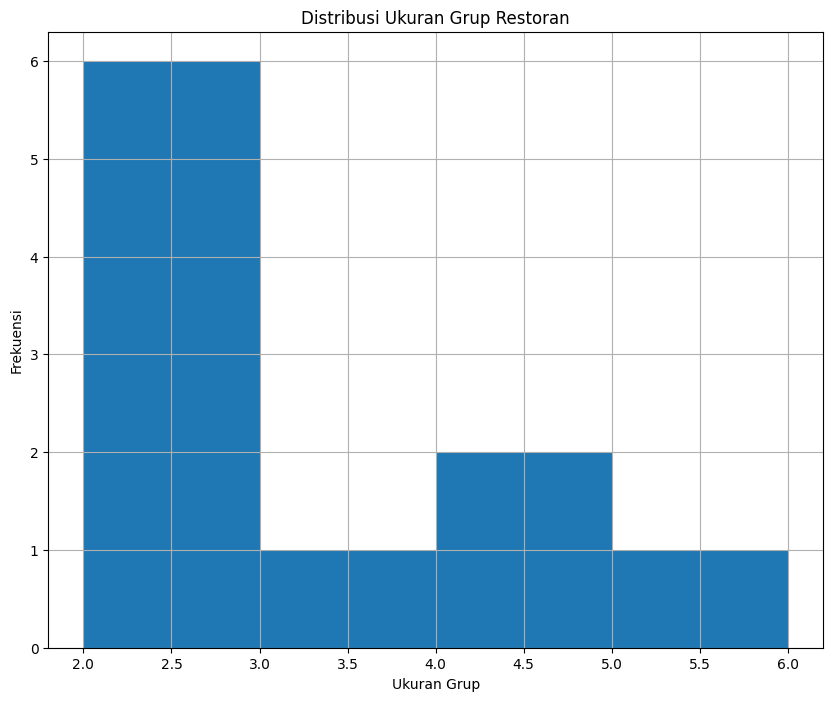

In [9]:
# Membuat histogram ukuran grup di restaurant_groups dan menampilkan plot
plt.hist(restaurant_groups['group_size'], bins=[2, 3, 4, 5, 6])
plt.xlabel('Ukuran Grup')
plt.ylabel('Frekuensi')
plt.title('Distribusi Ukuran Grup Restoran')
plt.grid(True)
plt.show()


In [29]:
# Create probability distribution
size_dist = restaurant_groups['group_size'] / restaurant_groups.shape[0]

# Reset index and rename columns
size_dist = size_dist.reset_index()
size_dist.columns = ['group_size', 'prob']

# Print the probability distribution
print(size_dist)

# Calculate expected value
expected_value = (size_dist['group_size'] * size_dist['prob']).sum()
print(expected_value)

# Subset groups of size 4 or more
groups_4_or_more = size_dist[size_dist['group_size'] >= 4]

# Sum the probabilities of groups of size 4 or more
prob_4_or_more = groups_4_or_more['prob'].sum()
print(prob_4_or_more)

   group_size  prob
0           0   0.2
1           1   0.4
2           2   0.6
3           3   0.2
4           4   0.2
5           5   0.2
6           6   0.3
7           7   0.2
8           8   0.4
9           9   0.2
12.200000000000001
1.4999999999999998


In [32]:
# Membuat distribusi probabilitas
size_dist = restaurant_groups['group_size'] / restaurant_groups.shape[0]

# Mengatur ulang indeks dan mengganti nama kolom
size_dist = size_dist.reset_index()
size_dist.columns = ['ukuran_grup', 'probabilitas']

# Menampilkan distribusi probabilitas
print(size_dist)

# Menghitung nilai harapan
nilai_harapan = (size_dist['ukuran_grup'] * size_dist['probabilitas']).sum()
print(nilai_harapan)

# Mengambil subset grup dengan ukuran 4 atau lebih
grup_4_atau_lebih = size_dist[size_dist['ukuran_grup'] >= 4]

# Menjumlahkan probabilitas grup dengan ukuran 4 atau lebih
prob_4_atau_lebih = grup_4_atau_lebih['probabilitas'].sum()
print(prob_4_atau_lebih)

   ukuran_grup  probabilitas
0            0           0.2
1            1           0.4
2            2           0.6
3            3           0.2
4            4           0.2
5            5           0.2
6            6           0.3
7            7           0.2
8            8           0.4
9            9           0.2
12.200000000000001
1.4999999999999998


In [33]:
from scipy.stats import uniform

# Min dan max waktu tunggu untuk back-up yang terjadi setiap 30 menit
min_time = 0
max_time = 30

# Fungsi untuk menghitung probabilitas menunggu kurang dari waktu tertentu
def prob_less_than(time):
    return uniform.cdf(time, min_time, max_time)

# Fungsi untuk menghitung probabilitas menunggu lebih dari waktu tertentu
def prob_greater_than(time):
    return 1 - prob_less_than(time)

# Fungsi untuk menghitung probabilitas menunggu dalam rentang waktu tertentu
def prob_between(start, end):
    return prob_less_than(end) - prob_less_than(start)

# Hitung probabilitas menunggu kurang dari 5 menit
prob_less_than_5 = prob_less_than(5)
print(f"Probabilitas menunggu kurang dari 5 menit: {prob_less_than_5:.4f}")

# Hitung probabilitas menunggu lebih dari 5 menit
prob_greater_than_5 = prob_greater_than(5)
print(f"Probabilitas menunggu lebih dari 5 menit: {prob_greater_than_5:.4f}")

# Hitung probabilitas menunggu antara 10 dan 20 menit
prob_between_10_and_20 = prob_between(10, 20)
print(f"Probabilitas menunggu antara 10 dan 20 menit: {prob_between_10_and_20:.4f}")

Probabilitas menunggu kurang dari 5 menit: 0.1667
Probabilitas menunggu lebih dari 5 menit: 0.8333
Probabilitas menunggu antara 10 dan 20 menit: 0.3333


10 waktu tunggu pertama: [ 7.144097    0.97455866  3.72802787  5.11644319  8.70602482 24.69140099
 23.98012075  3.19592668 25.1985306  17.89048629]


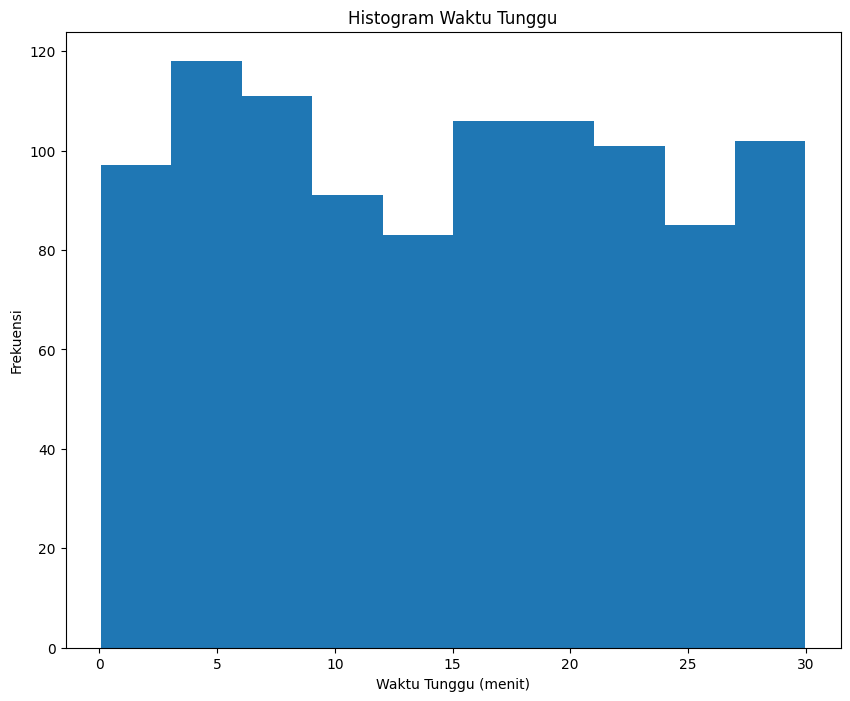

In [39]:
# Set random seed untuk reproducibility
np.random.seed(334)

# Menentukan min dan max waktu tunggu
min_time = 0
max_time = 30

# Menghasilkan 1000 waktu tunggu antara 0 dan 30 menit
wait_times = uniform.rvs(loc=min_time, scale=max_time, size=1000)

# Menampilkan 10 waktu tunggu pertama
print("10 waktu tunggu pertama:", wait_times[:10])

# Membuat histogram dari waktu tunggu yang disimulasikan
plt.hist(wait_times)
plt.title('Histogram Waktu Tunggu')
plt.xlabel('Waktu Tunggu (menit)')
plt.ylabel('Frekuensi')
plt.show()

In [42]:
from scipy.stats import binom

# Atur random seed untuk reproducibility
np.random.seed(10)

# Simulasikan satu deal
satu_deal = binom.rvs(n=1, p=0.3, size=1)
print("Hasil simulasi satu deal:", satu_deal[0])

# Simulasikan 3 deal dalam 1 minggu
minggu_deals = binom.rvs(n=3, p=0.3, size=1)
print("Hasil simulasi 3 deal dalam 1 minggu:", minggu_deals[0])

# Simulasikan 52 minggu dengan 3 deal per minggu
jumlah_minggu = 52
semua_deals = binom.rvs(n=3, p=0.3, size=jumlah_minggu)

# Hitung rata-rata deal yang berhasil per minggu
rata_rata_deals_per_minggu = np.mean(semua_deals)
print(f"Rata-rata deal yang berhasil per minggu: {rata_rata_deals_per_minggu:.2f}")

Hasil simulasi satu deal: 1
Hasil simulasi 3 deal dalam 1 minggu: 0
Rata-rata deal yang berhasil per minggu: 0.85


In [43]:
from scipy.stats import binom

# Probabilitas menutup 3 dari 3 deal
probabilitas_3 = binom.pmf(3, 3, 0.3)
print(f"Probabilitas menutup 3 dari 3 deal: {probabilitas_3:.4f}")

# Probabilitas menutup <= 1 deal dari 3 deal
probabilitas_kurang_dari_atau_sama_dengan_1 = binom.cdf(1, 3, 0.3)
print(f"Probabilitas menutup <= 1 deal dari 3 deal: {probabilitas_kurang_dari_atau_sama_dengan_1:.4f}")

# Probabilitas menutup > 1 deal dari 3 deal
probabilitas_lebih_dari_1 = 1 - binom.cdf(1, 3, 0.3)
print(f"Probabilitas menutup > 1 deal dari 3 deal: {probabilitas_lebih_dari_1:.4f}")

Probabilitas menutup 3 dari 3 deal: 0.0270
Probabilitas menutup <= 1 deal dari 3 deal: 0.7840
Probabilitas menutup > 1 deal dari 3 deal: 0.2160


In [44]:
# Jumlah deal
jumlah_deal = 3

# Jumlah yang diharapkan dimenangkan dengan tingkat kemenangan 30%
menang_30_persen = jumlah_deal * 0.3
print(f"Jumlah yang diharapkan dimenangkan dengan tingkat kemenangan 30%: {menang_30_persen:.2f}")

# Jumlah yang diharapkan dimenangkan dengan tingkat kemenangan 25%
menang_25_persen = jumlah_deal * 0.25
print(f"Jumlah yang diharapkan dimenangkan dengan tingkat kemenangan 25%: {menang_25_persen:.2f}")

# Jumlah yang diharapkan dimenangkan dengan tingkat kemenangan 35%
menang_35_persen = jumlah_deal * 0.35
print(f"Jumlah yang diharapkan dimenangkan dengan tingkat kemenangan 35%: {menang_35_persen:.2f}")

Jumlah yang diharapkan dimenangkan dengan tingkat kemenangan 30%: 0.90
Jumlah yang diharapkan dimenangkan dengan tingkat kemenangan 25%: 0.75
Jumlah yang diharapkan dimenangkan dengan tingkat kemenangan 35%: 1.05
